# AEF embeddings & ECOSTRESS land-surface temperature

Two more products, each with a one-figure recipe, read from the **bundled demo pack**
(`hackathon_demo_data/`, the **D_Chablis_Vineyard** AOI) — local files, no S3, no credentials.

- **AEF embeddings**: `aef_embeddings/2021/aef_D_Chablis_Vineyard_2021.tif` - 64-band float32 feature vectors per pixel (~10 m, native UTM; decimated for the demo). We compress 64 dims to 3 with PCA for a false-colour 'embedding map'.
- **ECOSTRESS LST**: `ecostress/cube.zarr` - land-surface temperature (K), 70 m, EPSG:2154. This is the **D_Chablis_Vineyard** AOI (the only ECOSTRESS site). Coverage is sparse - most timesteps are all-NaN, which the demo cube keeps so the coverage plot still tells that story.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import rasterio
import rioxarray  # noqa: F401  (registers the .rio accessor)
import geopandas as gpd

# Local demo pack - no S3, no credentials. See the repo README to download/unzip it.
DATA_DIR = Path("hackathon_demo_data")

## AEF embeddings -> PCA false colour

The COGs have no overviews, so we decimate on read with `out_shape` to keep it light, then run PCA (via SVD, no sklearn) on the valid pixels and map the first 3 components to RGB.

decimated to: (64, 214, 238)


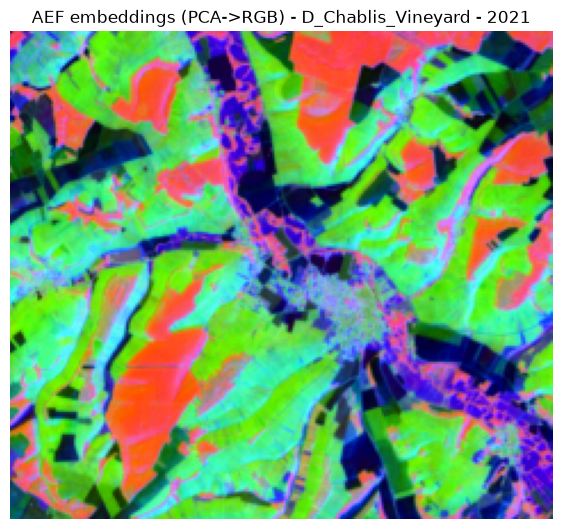

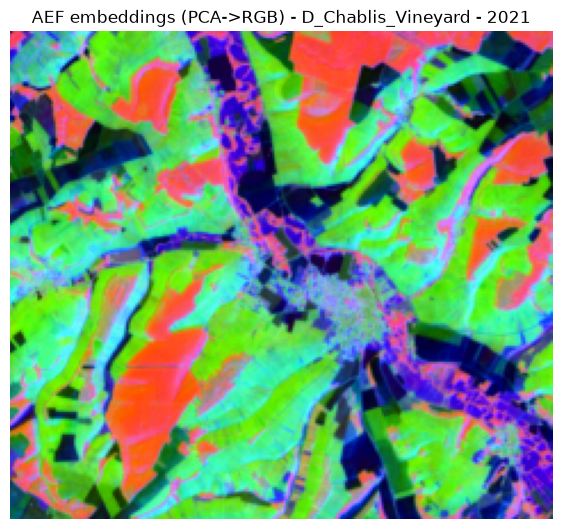

In [2]:
AOI = "D_Chablis_Vineyard"
YEAR = 2021
uri = DATA_DIR / "aef_embeddings" / str(YEAR) / f"aef_{AOI}_{YEAR}.tif"

with rasterio.open(uri) as src:
    scale = max(1, max(src.height, src.width) // 400)   # target ~400 px
    oh, ow = src.height // scale, src.width // scale
    emb = src.read(out_shape=(src.count, oh, ow)).astype("float32")  # (64, h, w)
print("decimated to:", emb.shape)

bands, h, w = emb.shape
flat = emb.reshape(bands, -1).T                 # (pixels, 64)
valid = np.isfinite(flat).all(axis=1)
X = flat[valid] - flat[valid].mean(axis=0)

_, _, vt = np.linalg.svd(X, full_matrices=False)
pcs = X @ vt[:3].T                              # first 3 components

rgb = np.full((h * w, 3), np.nan, "float32")
lo, hi = np.percentile(pcs, [2, 98], axis=0)
rgb[valid] = np.clip((pcs - lo) / (hi - lo), 0, 1)
rgb = rgb.reshape(h, w, 3)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(np.nan_to_num(rgb, nan=1.0))
ax.set_title(f"AEF embeddings (PCA->RGB) - {AOI} - {YEAR}")
ax.axis("off")
fig.savefig("04_aef_pca.png", dpi=120, bbox_inches="tight")
fig

## ECOSTRESS land-surface temperature

Drop the all-NaN timesteps (lossless), then plot one clear scene in degrees C with the AOI outline, plus the per-timestep valid-coverage series to show how gappy ECOSTRESS is.

valid timesteps: 192 of 638


/Users/matthewcourtis/Code/git-repos/hackathons/hackathon-june-2026/example-scripts/.venv/lib/python3.13/site-packages/xarray/core/dataarray.py:6439: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmax(dim, axis, keep_attrs, skipna)


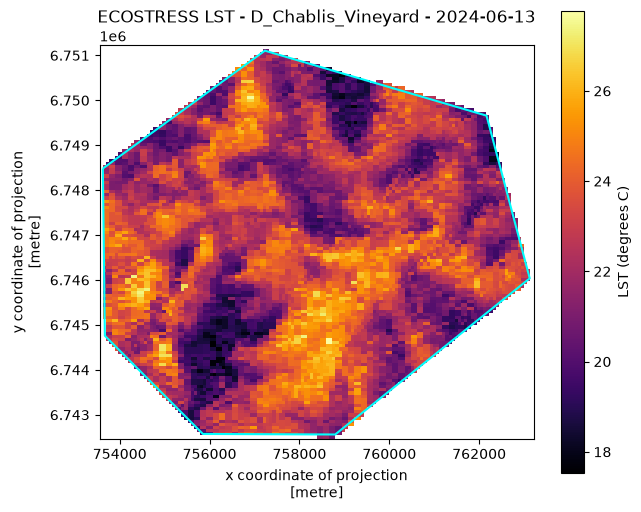

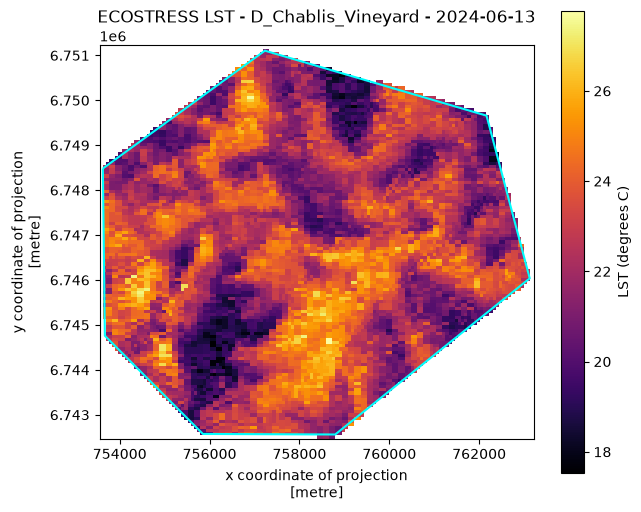

In [3]:
ds = xr.open_zarr(str(DATA_DIR / "ecostress" / "cube.zarr"))
ds = ds.rio.write_crs("EPSG:2154")          # spatial_ref isn't auto-detected

# fraction of valid pixels per timestep, and keep only non-empty scenes
coverage = ds["LST"].notnull().mean(dim=("y", "x")).compute()
ds_valid = ds.sel(time=coverage > 0)
print("valid timesteps:", ds_valid.sizes["time"], "of", ds.sizes["time"])

t = int(coverage.argmax())                  # best-covered scene
lst_c = ds["LST"].isel(time=t) - 273.15      # K -> degrees C
when = str(ds.time.values[t])[:10]

# AOI outline (local geojson, reproject to the cube CRS)
aoi = gpd.read_file(DATA_DIR / "boundary" / "D_Chablis_Vineyard_aoi.geojson").to_crs("EPSG:2154")

fig, ax = plt.subplots(figsize=(7, 6))
lst_c.plot.imshow(ax=ax, cmap="inferno", cbar_kwargs={"label": "LST (degrees C)"})
aoi.boundary.plot(ax=ax, color="cyan", lw=1.5)
ax.set_title(f"ECOSTRESS LST - D_Chablis_Vineyard - {when}")
ax.set_aspect("equal")
fig.savefig("04_ecostress_lst.png", dpi=120, bbox_inches="tight")
fig

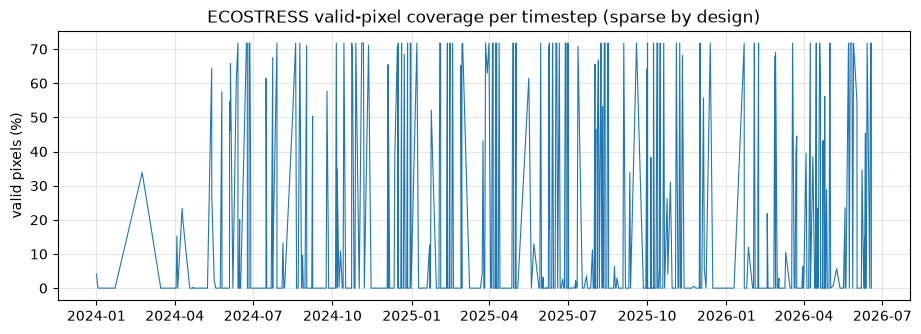

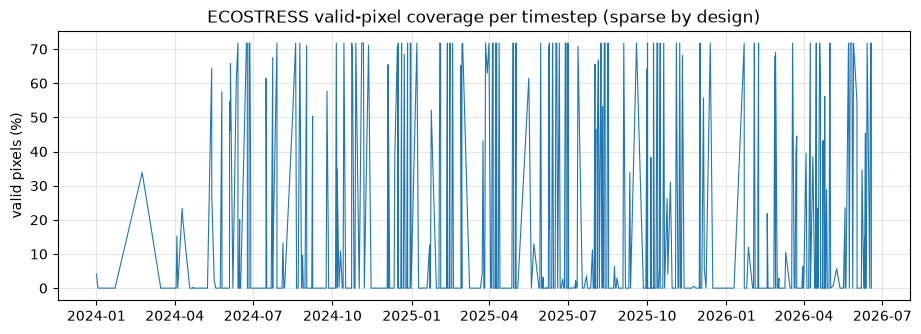

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(coverage.time, coverage * 100, lw=0.8)
ax.set_title("ECOSTRESS valid-pixel coverage per timestep (sparse by design)")
ax.set_ylabel("valid pixels (%)")
ax.grid(alpha=0.3)
fig.savefig("04_ecostress_coverage.png", dpi=120, bbox_inches="tight")
fig